## 0. Khởi tạo:

### 0.1. Cài đặt các thư viện:

In [1]:
!pip install --upgrade open_clip_torch transformers ftfy
import torch
import torch.nn as nn
from PIL import Image
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split, Subset
from torchvision.transforms import v2
import torch.optim as optim
import numpy as np
from tqdm.notebook import tqdm
from torchvision import datasets, models, transforms
from torch.optim.lr_scheduler import CosineAnnealingLR
from __future__ import print_function
import torch.nn.functional as F
import gc
import os
import timm
import seaborn as sns
import matplotlib.pyplot as plt
from collections import defaultdict
import open_clip
from transformers import (
    CLIPModel, CLIPTokenizer,
    AutoTokenizer,AutoModel,
    AlignModel
)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 21.7 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 94.6 MB/s eta 0:00:00:00:010:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 516.0/516.0 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 72.4 MB/s eta 0:00:00:00:01
  Attempting uninstall: safetensors
    Found existing installation: safetensors 0.7.0
    Uninstalling safetensors-0.7.0:
      Successfully uninstalled safetensors-0.7.0
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2
  Attempting uninstall: transformers
    Found existing installation: transformers 5.0.0
    Uninstalling transformers-5.0.0:
      Successfully uninstalled transformers-5.0.0


### 0.2. Lấy 15000 ảnh (15 ảnh/class) để làm dataset.

In [2]:
val_path = "/kaggle/input/datasets/titericz/imagenet1k-val/imagenet-val" #Co the thay doi

class Catch_Image(Dataset):
    def __init__(self, root_path, transform, num_samples):
        self.root_path = root_path
        self.transform  = transform
        self.num_samples = num_samples

        raw_classes = sorted([d for d in os.listdir(root_path) if os.path.isdir(os.path.join(root_path, d))])

        valid_classes = []
        temp_img_paths = []
        temp_label_texts = []
        for class_name in raw_classes:
            class_path = os.path.join(root_path, class_name)
            count = 0
            class_has_img = 0

            for img in os.listdir(class_path):
                if count >= self.num_samples:
                    break
                img_path = os.path.join(class_path, img)
                if os.path.isfile(img_path):
                    temp_img_paths.append(img_path)
                    temp_label_texts.append(class_name)
                    class_has_img = True
                    count += 1
                if class_has_img:
                    valid_classes.append(class_name)

            self.classes = sorted(list(set(valid_classes)))
            class_to_idx = {class_name : idx for idx, class_name in enumerate(self.classes)}
            self.img_paths = temp_img_paths
            self.labels = [class_to_idx[text_label] for text_label in temp_label_texts]

    def __getitem__(self, index): 
        img_path = self.img_paths[index] 
        image = Image.open(img_path).convert("RGB") 
        label = self.labels[index] 
        
        image = self.transform(image) 
        return image, label 
        
    def __len__(self): 
        return len(self.img_paths)

raw_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
])

test_dataset = Catch_Image(root_path=val_path, transform=raw_transform, num_samples=15) 
animal_names = test_dataset.classes 
print(f"Tổng số ảnh nạp thành công: {len(test_dataset)}")

Tổng số ảnh nạp thành công: 15000


### 0.3. Hàm huấn luyện & đánh giá UAP (Cho cả Vision/VLM và Targeted/Untargeted):

In [3]:
imagenet_categories = models.VGG16_Weights.DEFAULT.meta["categories"]
TARGET_CLASS = 35

def train_uap(model, dataloader, target_class=None, eps=16/255, alpha=1/255,
              epochs=5, temperature=1.0, mu=1.0):
    """
    target_class=None -> untargeted
    target_class=int  -> targeted
    
    """
    model.eval()
    v = torch.zeros((1, 3, 224, 224), device=device, requires_grad=True)
    g_momentum = torch.zeros_like(v)
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        running_loss = []
        pbar = tqdm(dataloader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)
        for imgs, labels in pbar:
            imgs = imgs.to(device)
            labels = labels.to(device)

            if target_class is not None:
                use_labels = torch.full((imgs.size(0),), target_class, dtype=torch.long, device=device)
            else:
                use_labels = labels

            perturbed = torch.clamp(imgs + v, 0.0, 1.0)
            outputs = model(perturbed) / temperature
            loss = criterion(outputs, use_labels)
            loss.backward()

            with torch.no_grad():
                grad = v.grad / (v.grad.abs().mean() + 1e-12)
                g_momentum = mu * g_momentum + grad
                if target_class is not None:
                    v -= alpha * g_momentum.sign()   # targeted: giảm loss -> đẩy VỀ target
                else:
                    v += alpha * g_momentum.sign()   # untargeted: tăng loss -> đẩy RA khỏi label thật
                v.clamp_(-eps, eps)
                v.grad.zero_()

            running_loss.append(loss.item())
            pbar.set_postfix({'Loss': f"{loss.item():.3f}"})
        print(f"  Epoch {epoch+1} - Avg Loss: {np.mean(running_loss):.4f}")

    return v.detach()


def evaluate_asr(model, test_loader, uap_tensor, target_class=None, temperature=1.0):
    """
    target_class=None -> tính untargeted ASR (pred != label)
    target_class=int  -> tính targeted ASR (pred == target_class)
    
    """
    model.eval()
    fooled = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(test_loader, desc="Evaluating ASR", leave=False):
            imgs = imgs.to(device)
            labels = labels.to(device)
            adv_imgs = torch.clamp(imgs + uap_tensor, 0.0, 1.0)
            adv_preds = (model(adv_imgs) / temperature).argmax(dim=-1)

            if target_class is not None:
                fooled += (adv_preds == target_class).sum().item()
            else:
                fooled += (adv_preds != labels).sum().item()
            total += labels.size(0)

    return (fooled / total) * 100.0 if total > 0 else 0.0

## 1. Vision model:
### 1.1. Nạp các model: 

In [4]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

class NormalizedModel(nn.Module):
    def __init__(self, base_model):
        super().__init__()
        self.base_model = base_model
        self.register_buffer('mean', torch.tensor([0.485, 0.456, 0.406]).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.229, 0.224, 0.225]).view(1, 3, 1, 1))

    def forward(self, x):
        return self.base_model((x - self.mean) / self.std)

def init_5_vision_models():
    raw_models = {
        'resnet50': models.resnet50(weights=models.ResNet50_Weights.DEFAULT),
        'vgg16': models.vgg16(weights=models.VGG16_Weights.DEFAULT),
        'vit_base': timm.create_model('vit_base_patch16_224', pretrained=True),
        'densenet121': models.densenet121(weights=models.DenseNet121_Weights.DEFAULT),
        'convnext_tiny': timm.create_model('convnext_tiny', pretrained=True)
    }
    models_dict = {}
    for name, m in raw_models.items():
        m.eval()
        for p in m.parameters():
            p.requires_grad = False
        models_dict[name] = NormalizedModel(m).to(device)
    return models_dict

vision_models = init_5_vision_models()
print("Đã nạp thành công:", list(vision_models.keys()))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 164MB/s] 


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:02<00:00, 198MB/s]  


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 144MB/s] 


model.safetensors:   0%|          | 0.00/114M [00:00<?, ?B/s]

Đã nạp thành công: ['resnet50', 'vgg16', 'vit_base', 'densenet121', 'convnext_tiny']


### 1.2. Zero-shot và lấy 3000 ảnh model đoán đúng (2000 để train, 1000 để test)

In [5]:
eval_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)

datasets_per_model = {}

print("Tìm 3 ảnh đúng/class cho từng mô hình...")

for model_name, model in vision_models.items():
    print(f"\n--- Đang đánh giá zero-shot: {model_name} ---")
    correct_indices_per_class = defaultdict(list)
    
    current_img_idx = 0
    with torch.no_grad():
        for imgs, labels in tqdm(eval_loader, desc=f"Eval {model_name}"):
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            preds = model(imgs).argmax(dim=-1)
            
            for i in range(len(labels)):
                lbl = labels[i].item()
                if preds[i] == lbl and len(correct_indices_per_class[lbl]) < 3:
                    correct_indices_per_class[lbl].append(current_img_idx + i)
            current_img_idx += len(labels)
            
            if len(correct_indices_per_class) == 1000 and all(len(v) == 3 for v in correct_indices_per_class.values()):
                break
                
    train_indices = []
    test_indices = []
    
    for c in range(len(test_dataset.classes)):
        samples = correct_indices_per_class.get(c, [])
        if len(samples) >= 3:
            train_indices.extend(samples[:2])
            test_indices.append(samples[2])
        elif len(samples) == 2:
            train_indices.extend(samples[:2])
        elif len(samples) == 1:
            train_indices.append(samples[0])
            
    print(f"[{model_name}] Số lượng ảnh: Train = {len(train_indices)} | Test = {len(test_indices)}")
    
    datasets_per_model[model_name] = {
        'train_loader': DataLoader(Subset(test_dataset, train_indices), batch_size=32, shuffle=True, num_workers=2),
        'test_loader': DataLoader(Subset(test_dataset, test_indices), batch_size=32, shuffle=False, num_workers=2)
    }

Tìm 3 ảnh đúng/class cho từng mô hình...

--- Đang đánh giá zero-shot: resnet50 ---


Eval resnet50:   0%|          | 0/235 [00:00<?, ?it/s]

[resnet50] Số lượng ảnh: Train = 1999 | Test = 997

--- Đang đánh giá zero-shot: vgg16 ---


Eval vgg16:   0%|          | 0/235 [00:00<?, ?it/s]

[vgg16] Số lượng ảnh: Train = 1995 | Test = 993

--- Đang đánh giá zero-shot: vit_base ---


...

[vit_base] Số lượng ảnh: Train = 2000 | Test = 997

--- Đang đánh giá zero-shot: densenet121 ---


Eval densenet121:   0%|          | 0/235 [00:00<?, ?it/s]

[densenet121] Số lượng ảnh: Train = 1998 | Test = 996

--- Đang đánh giá zero-shot: convnext_tiny ---


Eval convnext_tiny:   0%|          | 0/235 [00:00<?, ?it/s]

[convnext_tiny] Số lượng ảnh: Train = 2000 | Test = 998


### 1.3. Huấn luyện & đánh giá UAP Untargeted (Vision model)

In [6]:
os.makedirs("/kaggle/working/untargeted_uaps_vision_5models", exist_ok=True)
vision_untargeted_results = {}
for model_name, model in vision_models.items():
    print(f"\n=======================================================")
    print(f"Huấn luyện Untargeted UAP cho {model_name}...")
    train_ldr = datasets_per_model[model_name]['train_loader']
    test_ldr = datasets_per_model[model_name]['test_loader']

    uap_tensor = train_uap(model, train_ldr, target_class=None, eps=16/255, alpha=1/255, epochs=5)

    save_path = f"/kaggle/working/untargeted_uaps_vision_5models/uap_{model_name}.pt"
    torch.save(uap_tensor.cpu(), save_path)

    asr = evaluate_asr(model, test_ldr, uap_tensor, target_class=None)
    vision_untargeted_results[model_name] = asr
    print(f"-> Đã lưu: {save_path}")
    print(f"-> ASR trên tập test: {asr:.2f}%")

print("\n=== TỔNG HỢP ASR CỦA 5 VISION MODELS (UNTARGETED) ===")
for m, score in vision_untargeted_results.items():
    print(f"{m:15s}: {score:.2f}%")


Huấn luyện Untargeted UAP cho resnet50...


Epoch 1/5:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 1 - Avg Loss: 3.8454


Epoch 2/5:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 2 - Avg Loss: 7.7822


...

  Epoch 4 - Avg Loss: 8.3343


Epoch 5/5:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 5 - Avg Loss: 9.3131


Evaluating ASR:   0%|          | 0/32 [00:00<?, ?it/s]

-> Đã lưu: /kaggle/working/untargeted_uaps_vision_5models/uap_convnext_tiny.pt
-> ASR trên tập test: 91.48%

=== TỔNG HỢP ASR CỦA 5 VISION MODELS (UNTARGETED) ===
resnet50       : 97.69%
vgg16          : 98.79%
vit_base       : 95.59%
densenet121    : 96.79%
convnext_tiny  : 91.48%


### 1.4. Huấn luyện & đánh giá UAP Targeted (Vision model):

In [7]:
os.makedirs("/kaggle/working/targeted_uaps_vision_5models", exist_ok=True)
vision_targeted_results = {}
for model_name, model in vision_models.items():
    print(f"\n=======================================================")
    print(f"Huấn luyện Targeted UAP cho {model_name} (target_class={TARGET_CLASS})...")
    train_ldr = datasets_per_model[model_name]['train_loader']
    test_ldr = datasets_per_model[model_name]['test_loader']

    uap_tensor = train_uap(model, train_ldr, target_class=TARGET_CLASS, eps=16/255, alpha=1/255, epochs=5)

    save_path = f"/kaggle/working/targeted_uaps_vision_5models/uap_{model_name}.pt"
    torch.save(uap_tensor.cpu(), save_path)

    asr = evaluate_asr(model, test_ldr, uap_tensor, target_class=TARGET_CLASS)
    vision_targeted_results[model_name] = asr
    print(f"-> Đã lưu: {save_path}")
    print(f"-> ASR trên tập test: {asr:.2f}%")

print("\n=== TỔNG HỢP ASR CỦA 5 VISION MODELS (TARGETED) ===")
for m, score in vision_targeted_results.items():
    print(f"{m:15s}: {score:.2f}%")


Huấn luyện Targeted UAP cho resnet50 (target_class=35)...


Epoch 1/5:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 1 - Avg Loss: 4.5398


Epoch 2/5:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 2 - Avg Loss: 1.1745


...

  Epoch 4 - Avg Loss: 0.2072


Epoch 5/5:   0%|          | 0/63 [00:00<?, ?it/s]

  Epoch 5 - Avg Loss: 0.1559


Evaluating ASR:   0%|          | 0/32 [00:00<?, ?it/s]

-> Đã lưu: /kaggle/working/targeted_uaps_vision_5models/uap_convnext_tiny.pt
-> ASR trên tập test: 91.78%

=== TỔNG HỢP ASR CỦA 5 VISION MODELS (TARGETED) ===
resnet50       : 91.98%
vgg16          : 92.75%
vit_base       : 82.95%
densenet121    : 88.45%
convnext_tiny  : 91.78%


## 2. VLM model:
### 2.1. Khởi tạo 5 mô hình VLM (CLIP-family) cho zero-shot classification

Cell này nạp và chuẩn hoá 5 mô hình thị giác-ngôn ngữ (VLM) để dùng làm bộ phân loại zero-shot trên ImageNet, làm nền cho việc sinh và đánh giá UAP ở các bước sau.

- ***extract_tensor(out)***: hàm bóc tách tensor embedding một cách an toàn, vì mỗi loại model (HuggingFace, open_clip...) trả về output ở định dạng khác nhau (object có text_embeds/image_embeds, pooler_output, last_hidden_state, tuple, hoặc tensor).
- ***text_prompts***: sinh sẵn câu prompt dạng "a photo of a {tên lớp}" cho toàn bộ các lớp ImageNet.
- ***CLIPZeroShot***: wrapper cho CLIP gốc của HuggingFace (openai/clip-vit-base-patch32). Khi khởi tạo, encode sẵn toàn bộ text_prompts thành text_features (chuẩn hoá L2) và lưu làm buffer để không phải encode lại mỗi lần forward. Hàm forward chuẩn hoá ảnh đầu vào theo mean/std của CLIP, encode ảnh, rồi tính cosine similarity × logit_scale giữa ảnh và toàn bộ text embedding → ra logits zero-shot.
- ***OpenCLIPGenericZeroShot***: wrapper tổng quát hơn, dùng thư viện open_clip, có thể tái sử dụng cho nhiều kiến trúc/checkpoint khác nhau (open_clip, MetaCLIP, SigLIP, EVA-CLIP) chỉ bằng cách đổi tham số arch, dataset, và mean/std (SigLIP dùng mean/std = 0.5 thay vì chuẩn CLIP). Logic forward giống hệt CLIPZeroShot.

In [8]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")

def extract_tensor(out):
    if isinstance(out, torch.Tensor):
        return out
    if hasattr(out, "text_embeds") and out.text_embeds is not None:
        return out.text_embeds
    if hasattr(out, "image_embeds") and out.image_embeds is not None:
        return out.image_embeds
    if hasattr(out, "pooler_output") and out.pooler_output is not None:
        return out.pooler_output
    if hasattr(out, "last_hidden_state") and out.last_hidden_state is not None:
        return out.last_hidden_state[:, 0]
    return out[0]

text_prompts = [f"a photo of a {cat.replace('_', ' ')}" for cat in imagenet_categories]

class CLIPZeroShot(nn.Module):
    def __init__(self, model_name="openai/clip-vit-base-patch32"):
        super().__init__()
        self.model = CLIPModel.from_pretrained(model_name).to(device).eval()
        tokenizer = CLIPTokenizer.from_pretrained(model_name)
        
        self.register_buffer('mean', torch.tensor([0.48145466, 0.4578275, 0.40821073], device=device).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor([0.26862954, 0.26130258, 0.27577711], device=device).view(1, 3, 1, 1))
        
        with torch.inference_mode():
            feats = []
            for i in range(0, len(text_prompts), 256):
                tokens = tokenizer(text_prompts[i:i+256], padding=True, return_tensors="pt").to(device)
                raw_text = self.model.get_text_features(**tokens)
                feats.append(extract_tensor(raw_text))
            text_feats = torch.cat(feats, dim=0)
            self.register_buffer('text_features', F.normalize(text_feats, dim=-1))

    def forward(self, x):
        x_norm = (x - self.mean) / self.std
        raw_img = self.model.get_image_features(pixel_values=x_norm)
        img_feats = F.normalize(extract_tensor(raw_img), dim=-1)
        return (img_feats @ self.text_features.T) * self.model.logit_scale.exp()

class OpenCLIPGenericZeroShot(nn.Module):
    def __init__(self, arch, dataset, mean=(0.48145466, 0.4578275, 0.40821073), std=(0.26862954, 0.26130258, 0.27577711)):
        super().__init__()
        self.model, _, _ = open_clip.create_model_and_transforms(arch, pretrained=dataset)
        self.model = self.model.to(device).eval()
        tokenizer = open_clip.get_tokenizer(arch)
        
        self.register_buffer('mean', torch.tensor(mean, device=device).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor(std, device=device).view(1, 3, 1, 1))
        
        with torch.inference_mode():
            feats = []
            for i in range(0, len(text_prompts), 256):
                tokens = tokenizer(text_prompts[i:i+256]).to(device)
                feats.append(self.model.encode_text(tokens))
            text_feats = torch.cat(feats, dim=0)
            self.register_buffer('text_features', F.normalize(text_feats, dim=-1))

    def forward(self, x):
        x_norm = (x - self.mean) / self.std
        img_feats = F.normalize(self.model.encode_image(x_norm), dim=-1)
        return (img_feats @ self.text_features.T) * self.model.logit_scale.exp()

torch.cuda.empty_cache()
gc.collect()

print("Đang nạp 5 mô hình VLM...")
vlm_models = {
    'clip': CLIPZeroShot().to(device),
    'open_clip': OpenCLIPGenericZeroShot('ViT-B-32', 'laion2b_s34b_b79k').to(device),
    'metaclip': OpenCLIPGenericZeroShot(
        'ViT-B-32-quickgelu',
        'metaclip_fullcc'
    ).to(device),
    'siglip': OpenCLIPGenericZeroShot('ViT-B-16-SigLIP', 'webli', mean=(0.5, 0.5, 0.5), std=(0.5, 0.5, 0.5)).to(device),
    'eva_clip': OpenCLIPGenericZeroShot('EVA02-B-16', 'merged2b_s8b_b131k').to(device)
}

for model in vlm_models.values():
    for p in model.parameters():
        p.requires_grad = False

print("Đã nạp và chuẩn hóa thành công 5 mô hình VLM:", list(vlm_models.keys()))

Device: cuda
Đang nạp 5 mô hình VLM...


config.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

open_clip_model.safetensors:   0%|          | 0.00/299M [00:00<?, ?B/s]

Đã nạp và chuẩn hóa thành công 5 mô hình VLM: ['clip', 'open_clip', 'metaclip', 'siglip', 'eva_clip']


### 1.2. Zero-shot và lấy 3000 ảnh model đoán đúng (2000 để train, 1000 để test)

In [9]:
eval_loader = DataLoader(test_dataset, batch_size=64, shuffle=False, num_workers=2)
vlm_datasets = {}

print("Bắt đầu lọc dữ liệu Zero-shot: 3 ảnh đúng / class...")

for model_name, model in vlm_models.items():
    print(f"\n--- Đang đánh giá zero-shot: {model_name} ---")
    correct_indices_per_class = defaultdict(list)
    current_img_idx = 0
    
    with torch.no_grad():
        for imgs, labels in tqdm(eval_loader, desc=f"Eval {model_name}"):
            imgs = imgs.to(device)
            labels = labels.to(device)
            
            logits = model(imgs)
            preds = logits.argmax(dim=-1)
            
            for i in range(len(labels)):
                lbl = labels[i].item()
                if preds[i] == lbl and len(correct_indices_per_class[lbl]) < 3:
                    correct_indices_per_class[lbl].append(current_img_idx + i)
            current_img_idx += len(labels)
            
            if len(correct_indices_per_class) == 1000 and all(len(v) == 3 for v in correct_indices_per_class.values()):
                break
                
    train_indices = []
    test_indices = []
    
    for c in range(len(test_dataset.classes)):
        samples = correct_indices_per_class.get(c, [])
        if len(samples) >= 3:
            train_indices.extend(samples[:2])
            test_indices.append(samples[2])
        elif len(samples) == 2:
            train_indices.extend(samples[:2])
        elif len(samples) == 1:
            train_indices.append(samples[0])
            
    print(f"[{model_name}] Số lượng ảnh thu thập: Train = {len(train_indices)} | Test = {len(test_indices)}")
    
    vlm_datasets[model_name] = {
        'train_loader': DataLoader(Subset(test_dataset, train_indices), batch_size=32, shuffle=True, num_workers=2),
        'test_loader': DataLoader(Subset(test_dataset, test_indices), batch_size=32, shuffle=False, num_workers=2)
    }

Bắt đầu lọc dữ liệu Zero-shot: 3 ảnh đúng / class...

--- Đang đánh giá zero-shot: clip ---


Eval clip:   0%|          | 0/235 [00:00<?, ?it/s]

[clip] Số lượng ảnh thu thập: Train = 1899 | Test = 903

--- Đang đánh giá zero-shot: open_clip ---


Eval open_clip:   0%|          | 0/235 [00:00<?, ?it/s]

[open_clip] Số lượng ảnh thu thập: Train = 1916 | Test = 924

--- Đang đánh giá zero-shot: metaclip ---


...

[metaclip] Số lượng ảnh thu thập: Train = 1912 | Test = 932

--- Đang đánh giá zero-shot: siglip ---


Eval siglip:   0%|          | 0/235 [00:00<?, ?it/s]

[siglip] Số lượng ảnh thu thập: Train = 1959 | Test = 967

--- Đang đánh giá zero-shot: eva_clip ---


Eval eva_clip:   0%|          | 0/235 [00:00<?, ?it/s]

[eva_clip] Số lượng ảnh thu thập: Train = 1916 | Test = 937


### 2.3. Gỡ cờ inference_mode khỏi buffer của các model VLM

Các buffer text_features, mean, std được tạo bên trong torch.inference_mode() ở cell trước nên bị gắn cờ "inference tensor" — nếu giữ nguyên sẽ gây lỗi khi tính gradient để sinh UAP về sau.

In [10]:
print("Đang gỡ bỏ cờ inference_mode cho 5 VLM models...")
with torch.inference_mode(False):
    for model in vlm_models.values():
        if hasattr(model, 'text_features'):
            new_tf = model.text_features.clone().detach()
            model.text_features = new_tf
        if hasattr(model, 'mean'):
            new_mean = model.mean.clone().detach()
            model.mean = new_mean
        if hasattr(model, 'std'):
            new_std = model.std.clone().detach()
            model.std = new_std

print("Kiểm tra trạng thái buffers:")
for name, model in vlm_models.items():
    tf_check = model.text_features.is_inference() if hasattr(model, 'text_features') else None
    mean_check = model.mean.is_inference() if hasattr(model, 'mean') else None
    std_check = model.std.is_inference() if hasattr(model, 'std') else None
    print(f"{name}: text_features_inference={tf_check}, mean_inference={mean_check}, std_inference={std_check}")

Đang gỡ bỏ cờ inference_mode cho 5 VLM models...
Kiểm tra trạng thái buffers:
clip: text_features_inference=False, mean_inference=False, std_inference=False
open_clip: text_features_inference=False, mean_inference=False, std_inference=False
metaclip: text_features_inference=False, mean_inference=False, std_inference=False
siglip: text_features_inference=False, mean_inference=False, std_inference=False
eva_clip: text_features_inference=False, mean_inference=False, std_inference=False


### 2.4. Huấn luyện & đánh giá UAP Untargeted (VLM)

In [11]:
os.makedirs("/kaggle/working/untargeted_uaps_vlm_5models", exist_ok=True)
vlm_untargeted_results = {}
model_temperatures = {'clip': 1.0, 'open_clip': 1.0, 'eva_clip': 1.0, 'siglip': 1.0, 'metaclip': 1.0}

for model_name, model in vlm_models.items():
    print(f"\n=======================================================")
    print(f"Huấn luyện Untargeted UAP cho {model_name}...")
    train_ldr = vlm_datasets[model_name]['train_loader']
    test_ldr = vlm_datasets[model_name]['test_loader']
    temp = model_temperatures.get(model_name, 1.0)

    uap_tensor = train_uap(model, train_ldr, target_class=None, eps=16/255, alpha=1/255, epochs=5, temperature=temp)

    save_path = f"/kaggle/working/untargeted_uaps_vlm_5models/uap_{model_name}.pt"
    torch.save(uap_tensor.cpu(), save_path)

    asr = evaluate_asr(model, test_ldr, uap_tensor, target_class=None, temperature=temp)
    vlm_untargeted_results[model_name] = asr
    print(f"-> Đã lưu: {save_path}")
    print(f"-> ASR trên tập test: {asr:.2f}%")

print("\n=== TỔNG HỢP ASR CỦA 5 VLM MODELS (UNTARGETED) ===")
for m, score in vlm_untargeted_results.items():
    print(f"{m:15s}: {score:.2f}%")


Huấn luyện Untargeted UAP cho clip...


Epoch 1/5:   0%|          | 0/60 [00:00<?, ?it/s]

  Epoch 1 - Avg Loss: 2.9613


Epoch 2/5:   0%|          | 0/60 [00:00<?, ?it/s]

  Epoch 2 - Avg Loss: 10.2640


...

  Epoch 4 - Avg Loss: 24.2658


Epoch 5/5:   0%|          | 0/60 [00:00<?, ?it/s]

  Epoch 5 - Avg Loss: 25.7540


Evaluating ASR:   0%|          | 0/30 [00:00<?, ?it/s]

-> Đã lưu: /kaggle/working/untargeted_uaps_vlm_5models/uap_eva_clip.pt
-> ASR trên tập test: 98.61%

=== TỔNG HỢP ASR CỦA 5 VLM MODELS (UNTARGETED) ===
clip           : 99.11%
open_clip      : 97.73%
metaclip       : 98.82%
siglip         : 99.07%
eva_clip       : 98.61%


### 2.5. Huấn luyện & đánh giá UAP Targeted (VLM)

In [12]:
os.makedirs("/kaggle/working/targeted_uaps_vlm_5models", exist_ok=True)
vlm_targeted_results = {}
model_temperatures = {'clip': 1.0, 'open_clip': 1.0, 'eva_clip': 1.0, 'siglip': 1.0, 'metaclip': 1.0}

for model_name, model in vlm_models.items():
    print(f"\n=======================================================")
    print(f"Huấn luyện Targeted UAP cho {model_name} (target_class={TARGET_CLASS})...")
    train_ldr = vlm_datasets[model_name]['train_loader']
    test_ldr = vlm_datasets[model_name]['test_loader']
    temp = model_temperatures.get(model_name, 1.0)

    uap_tensor = train_uap(model, train_ldr, target_class=TARGET_CLASS, eps=16/255, alpha=1/255, epochs=5, temperature=temp)

    save_path = f"/kaggle/working/targeted_uaps_vlm_5models/uap_{model_name}.pt"
    torch.save(uap_tensor.cpu(), save_path)

    asr = evaluate_asr(model, test_ldr, uap_tensor, target_class=TARGET_CLASS, temperature=temp)
    vlm_targeted_results[model_name] = asr
    print(f"-> Đã lưu: {save_path}")
    print(f"-> ASR trên tập test: {asr:.2f}%")

print("\n=== TỔNG HỢP ASR CỦA 5 VLM MODELS (TARGETED) ===")
for m, score in vlm_targeted_results.items():
    print(f"{m:15s}: {score:.2f}%")


Huấn luyện Targeted UAP cho clip (target_class=35)...


Epoch 1/5:   0%|          | 0/60 [00:00<?, ?it/s]

  Epoch 1 - Avg Loss: 8.4357


Epoch 2/5:   0%|          | 0/60 [00:00<?, ?it/s]

  Epoch 2 - Avg Loss: 0.9771


...

  Epoch 4 - Avg Loss: 0.5968


Epoch 5/5:   0%|          | 0/60 [00:00<?, ?it/s]

  Epoch 5 - Avg Loss: 0.3357


Evaluating ASR:   0%|          | 0/30 [00:00<?, ?it/s]

-> Đã lưu: /kaggle/working/targeted_uaps_vlm_5models/uap_eva_clip.pt
-> ASR trên tập test: 91.68%

=== TỔNG HỢP ASR CỦA 5 VLM MODELS (TARGETED) ===
clip           : 94.13%
open_clip      : 73.05%
metaclip       : 83.26%
siglip         : 89.66%
eva_clip       : 91.68%


## 3. Vẽ hình các nhiễu:

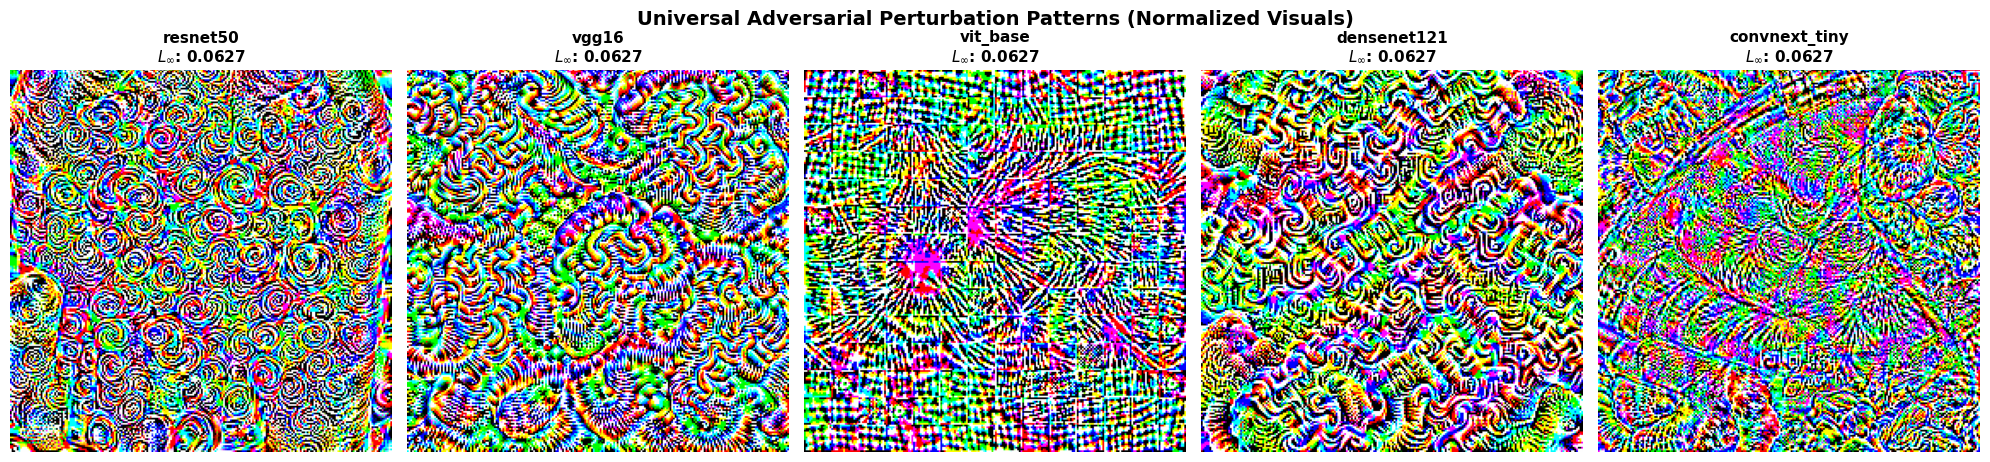


=== THỐNG KÊ CHI TIẾT 5 MA TRẬN NHIỄU (VISION/UNTARGETED) ===
        Model             L_inf L2 Norm     Min    Max     Mean
     resnet50 0.0627 (16.0/255)   23.57 -0.0627 0.0627 -0.00001
        vgg16 0.0627 (16.0/255)   23.43 -0.0627 0.0627 -0.00004
     vit_base 0.0627 (16.0/255)   24.02 -0.0627 0.0627  0.00027
  densenet121 0.0627 (16.0/255)   23.67 -0.0627 0.0627 -0.00053
convnext_tiny 0.0627 (16.0/255)   23.48 -0.0627 0.0627 -0.00023


In [16]:
model_names = ['resnet50','vgg16','vit_base','densenet121','convnext_tiny']
uap_dir = "/kaggle/working/untargeted_uaps_vision_5models"

stats = []
fig, axes = plt.subplots(1, len(model_names), figsize=(20, 4.5))

for idx, name in enumerate(model_names):
    file_path = os.path.join(uap_dir, f"uap_{name}.pt")
    
    if not os.path.exists(file_path):
        print(f"Không tìm thấy file: {file_path}")
        continue
        
    uap_tensor = torch.load(file_path, map_location='cpu')
    
    l_inf = uap_tensor.abs().max().item()
    l_2 = torch.norm(uap_tensor, p=2).item()
    min_val = uap_tensor.min().item()
    max_val = uap_tensor.max().item()
    mean_val = uap_tensor.mean().item()
    
    stats.append({
        "Model": name,
        "L_inf": f"{l_inf:.4f} ({l_inf * 255:.1f}/255)",
        "L2 Norm": f"{l_2:.2f}",
        "Min": f"{min_val:.4f}",
        "Max": f"{max_val:.4f}",
        "Mean": f"{mean_val:.5f}"
    })
    
    uap_np = uap_tensor.squeeze(0).permute(1, 2, 0).numpy()
    disp_img = (uap_np - uap_np.min()) / (uap_np.max() - uap_np.min() + 1e-8)
    
    axes[idx].imshow(disp_img)
    axes[idx].set_title(f"{name}\n$L_\\infty$: {l_inf:.4f}", fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("Universal Adversarial Perturbation Patterns (Normalized Visuals)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

df_stats = pd.DataFrame(stats)
print("\n=== THỐNG KÊ CHI TIẾT 5 MA TRẬN NHIỄU (VISION/UNTARGETED) ===")
print(df_stats.to_string(index=False))

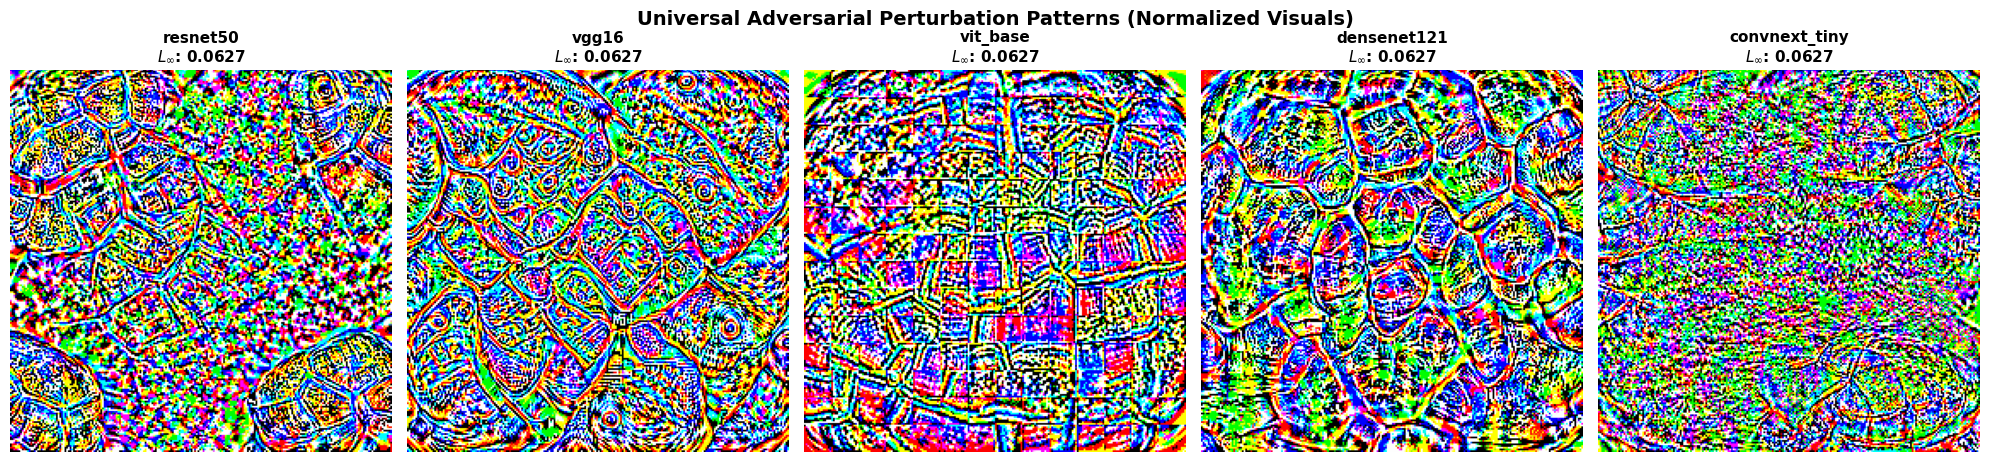


=== THỐNG KÊ CHI TIẾT 5 MA TRẬN NHIỄU (VISION/TARGETED) ===
        Model             L_inf L2 Norm     Min    Max     Mean
     resnet50 0.0627 (16.0/255)   23.57 -0.0627 0.0627 -0.00078
        vgg16 0.0627 (16.0/255)   23.76 -0.0627 0.0627 -0.00047
     vit_base 0.0627 (16.0/255)   23.94 -0.0627 0.0627  0.00058
  densenet121 0.0627 (16.0/255)   23.72 -0.0627 0.0627 -0.00180
convnext_tiny 0.0627 (16.0/255)   23.44 -0.0627 0.0627 -0.00144


In [17]:
model_names = ['resnet50','vgg16','vit_base','densenet121','convnext_tiny']
uap_dir = "/kaggle/working/targeted_uaps_vision_5models"

stats = []
fig, axes = plt.subplots(1, len(model_names), figsize=(20, 4.5))

for idx, name in enumerate(model_names):
    file_path = os.path.join(uap_dir, f"uap_{name}.pt")
    
    if not os.path.exists(file_path):
        print(f"Không tìm thấy file: {file_path}")
        continue
        
    uap_tensor = torch.load(file_path, map_location='cpu')
    
    l_inf = uap_tensor.abs().max().item()
    l_2 = torch.norm(uap_tensor, p=2).item()
    min_val = uap_tensor.min().item()
    max_val = uap_tensor.max().item()
    mean_val = uap_tensor.mean().item()
    
    stats.append({
        "Model": name,
        "L_inf": f"{l_inf:.4f} ({l_inf * 255:.1f}/255)",
        "L2 Norm": f"{l_2:.2f}",
        "Min": f"{min_val:.4f}",
        "Max": f"{max_val:.4f}",
        "Mean": f"{mean_val:.5f}"
    })
    
    uap_np = uap_tensor.squeeze(0).permute(1, 2, 0).numpy()
    disp_img = (uap_np - uap_np.min()) / (uap_np.max() - uap_np.min() + 1e-8)
    
    axes[idx].imshow(disp_img)
    axes[idx].set_title(f"{name}\n$L_\\infty$: {l_inf:.4f}", fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("Universal Adversarial Perturbation Patterns (Normalized Visuals)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

df_stats = pd.DataFrame(stats)
print("\n=== THỐNG KÊ CHI TIẾT 5 MA TRẬN NHIỄU (VISION/TARGETED) ===")
print(df_stats.to_string(index=False))

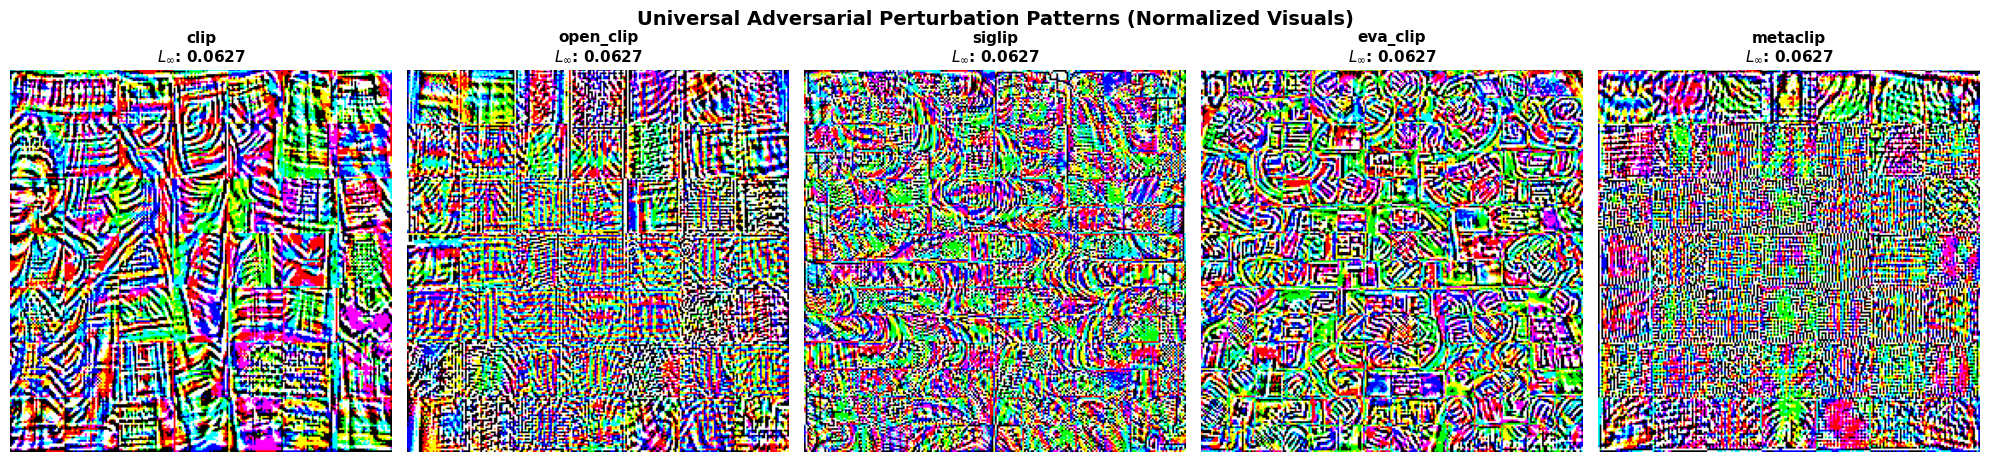


=== THỐNG KÊ CHI TIẾT 5 MA TRẬN NHIỄU (VLM/UNTARGETED) ===
    Model             L_inf L2 Norm     Min    Max     Mean
     clip 0.0627 (16.0/255)   24.05 -0.0627 0.0627  0.00029
open_clip 0.0627 (16.0/255)   24.14 -0.0627 0.0627 -0.00002
   siglip 0.0627 (16.0/255)   23.82 -0.0627 0.0627  0.00024
 eva_clip 0.0627 (16.0/255)   23.85 -0.0627 0.0627 -0.00029
 metaclip 0.0627 (16.0/255)   24.17 -0.0627 0.0627  0.00004


In [18]:
model_names = ['clip', 'open_clip', 'siglip', 'eva_clip', 'metaclip']
uap_dir = "/kaggle/working/untargeted_uaps_vlm_5models"

stats = []
fig, axes = plt.subplots(1, len(model_names), figsize=(20, 4.5))

for idx, name in enumerate(model_names):
    file_path = os.path.join(uap_dir, f"uap_{name}.pt")
    
    if not os.path.exists(file_path):
        print(f"Không tìm thấy file: {file_path}")
        continue
        
    uap_tensor = torch.load(file_path, map_location='cpu')
    
    l_inf = uap_tensor.abs().max().item()
    l_2 = torch.norm(uap_tensor, p=2).item()
    min_val = uap_tensor.min().item()
    max_val = uap_tensor.max().item()
    mean_val = uap_tensor.mean().item()
    
    stats.append({
        "Model": name,
        "L_inf": f"{l_inf:.4f} ({l_inf * 255:.1f}/255)",
        "L2 Norm": f"{l_2:.2f}",
        "Min": f"{min_val:.4f}",
        "Max": f"{max_val:.4f}",
        "Mean": f"{mean_val:.5f}"
    })
    
    uap_np = uap_tensor.squeeze(0).permute(1, 2, 0).numpy()
    disp_img = (uap_np - uap_np.min()) / (uap_np.max() - uap_np.min() + 1e-8)
    
    axes[idx].imshow(disp_img)
    axes[idx].set_title(f"{name}\n$L_\\infty$: {l_inf:.4f}", fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("Universal Adversarial Perturbation Patterns (Normalized Visuals)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

df_stats = pd.DataFrame(stats)
print("\n=== THỐNG KÊ CHI TIẾT 5 MA TRẬN NHIỄU (VLM/UNTARGETED) ===")
print(df_stats.to_string(index=False))

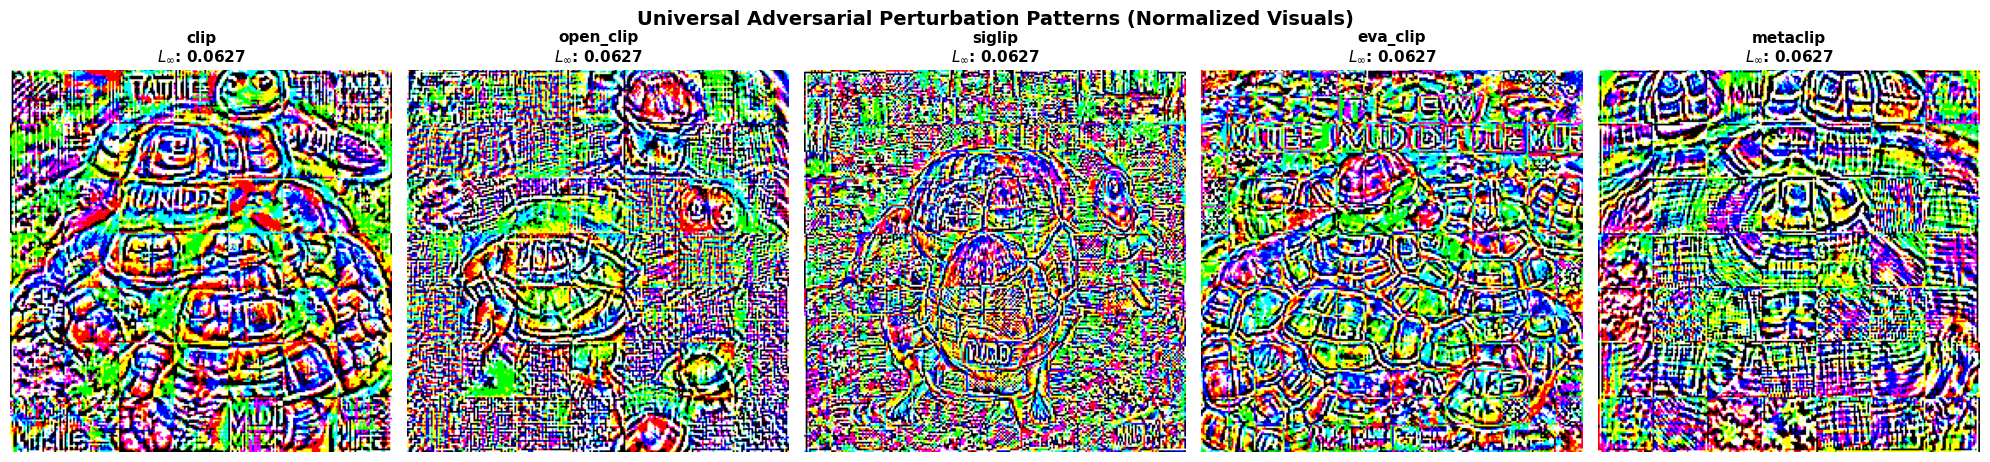


=== THỐNG KÊ CHI TIẾT 5 MA TRẬN NHIỄU (VLM/TARGETED) ===
    Model             L_inf L2 Norm     Min    Max     Mean
     clip 0.0627 (16.0/255)   23.94 -0.0627 0.0627 -0.00123
open_clip 0.0627 (16.0/255)   24.07 -0.0627 0.0627  0.00010
   siglip 0.0627 (16.0/255)   23.75 -0.0627 0.0627  0.00026
 eva_clip 0.0627 (16.0/255)   23.76 -0.0627 0.0627 -0.00101
 metaclip 0.0627 (16.0/255)   24.09 -0.0627 0.0627 -0.00023


In [19]:
model_names = ['clip', 'open_clip', 'siglip', 'eva_clip', 'metaclip']
uap_dir = "/kaggle/working/targeted_uaps_vlm_5models"

stats = []
fig, axes = plt.subplots(1, len(model_names), figsize=(20, 4.5))

for idx, name in enumerate(model_names):
    file_path = os.path.join(uap_dir, f"uap_{name}.pt")
    
    if not os.path.exists(file_path):
        print(f"Không tìm thấy file: {file_path}")
        continue
        
    uap_tensor = torch.load(file_path, map_location='cpu')
    
    l_inf = uap_tensor.abs().max().item()
    l_2 = torch.norm(uap_tensor, p=2).item()
    min_val = uap_tensor.min().item()
    max_val = uap_tensor.max().item()
    mean_val = uap_tensor.mean().item()
    
    stats.append({
        "Model": name,
        "L_inf": f"{l_inf:.4f} ({l_inf * 255:.1f}/255)",
        "L2 Norm": f"{l_2:.2f}",
        "Min": f"{min_val:.4f}",
        "Max": f"{max_val:.4f}",
        "Mean": f"{mean_val:.5f}"
    })
    
    uap_np = uap_tensor.squeeze(0).permute(1, 2, 0).numpy()
    disp_img = (uap_np - uap_np.min()) / (uap_np.max() - uap_np.min() + 1e-8)
    
    axes[idx].imshow(disp_img)
    axes[idx].set_title(f"{name}\n$L_\\infty$: {l_inf:.4f}", fontsize=11, fontweight='bold')
    axes[idx].axis('off')

plt.suptitle("Universal Adversarial Perturbation Patterns (Normalized Visuals)", fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

df_stats = pd.DataFrame(stats)
print("\n=== THỐNG KÊ CHI TIẾT 5 MA TRẬN NHIỄU (VLM/TARGETED) ===")
print(df_stats.to_string(index=False))